In [1]:
# =========================================
# STEP 0: IMPORT LIBRARIES
# =========================================
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib


In [2]:
# =========================================
# STEP 0.5: LOCAL NOTE
# =========================================
# No Google Drive mount needed. This notebook runs locally.


In [3]:
# =========================================
# STEP 1: LOAD DATASET
# =========================================
csv_candidates = [
    Path('Vegetables_fruit_prices_with_climate_130000_2020_to_2025.csv'),
    Path('model/Vegetables_fruit_prices_with_climate_130000_2020_to_2025.csv'),
]

dataset_path = next((p for p in csv_candidates if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError('CSV not found. Place it in current folder or model/ folder.')

df = pd.read_csv(dataset_path, encoding='latin1', low_memory=False)
df.columns = [
    c.replace('??C', '?C').replace('????C', '?C').replace('?C', '?C').replace('?C', '?C')
    for c in df.columns
]
temp_col = next((c for c in df.columns if c.startswith('Temperature')), None)
if temp_col is None:
    raise KeyError('Temperature column not found in dataset')
print(f'Loaded dataset from: {dataset_path.resolve()}')
print(f'Using temperature column: {temp_col}')


Loaded dataset from: C:\Users\banum\Desktop\fresh-ai-trade-main\model\Vegetables_fruit_prices_with_climate_130000_2020_to_2025.csv
Using temperature column: Temperature (ï¿½C)


In [4]:
# =========================================
# STEP 2: CLEAN NUMERIC COLUMNS
# =========================================
numeric_columns = [
    temp_col,
    'Rainfall (mm)',
    'Humidity (%)',
    'Crop Yield Impact Score',
    'fruit_Price per Unit (LKR/kg)'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)


In [5]:
# =========================================
# STEP 3: ENCODE CATEGORICAL VARIABLES
# =========================================
region_encoder = LabelEncoder()
fruit_encoder = LabelEncoder()

df['Region_enc'] = region_encoder.fit_transform(df['Region'])
df['fruit_enc'] = fruit_encoder.fit_transform(df['fruit_Commodity'])


In [6]:
# =========================================
# STEP 4: CREATE INTERACTION FEATURES
# =========================================
df['fruit_Region'] = df['fruit_enc'] * df['Region_enc']
df['Temp_Rain'] = df[temp_col] * df['Rainfall (mm)']
df['Temp_Hum'] = df[temp_col] * df['Humidity (%)']


In [7]:
# =========================================
# STEP 5: SELECT FEATURES & TARGET
# =========================================
feature_cols = [
    temp_col,
    'Rainfall (mm)',
    'Humidity (%)',
    'Crop Yield Impact Score',
    'Region_enc',
    'fruit_enc',
    'fruit_Region',
    'Temp_Rain',
    'Temp_Hum'
]
X = df[feature_cols]
y = df['fruit_Price per Unit (LKR/kg)']


In [8]:
# =========================================
# STEP 6: TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# =========================================
# STEP 7: TRAIN OPTIMIZED RANDOM FOREST
# =========================================
rf_model = RandomForestRegressor(
    n_estimators=700,
    max_depth=30,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [10]:
# =========================================
# STEP 8: MAKE PREDICTIONS
# =========================================
y_pred = rf_model.predict(X_test)

In [11]:
# =========================================
# STEP 9: MODEL EVALUATION
# =========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Optimized Random Forest Model Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Optimized Random Forest Model Evaluation:
MAE: 14.769066743959852
RMSE: 22.171154900555276
R²: 0.9712077538348628


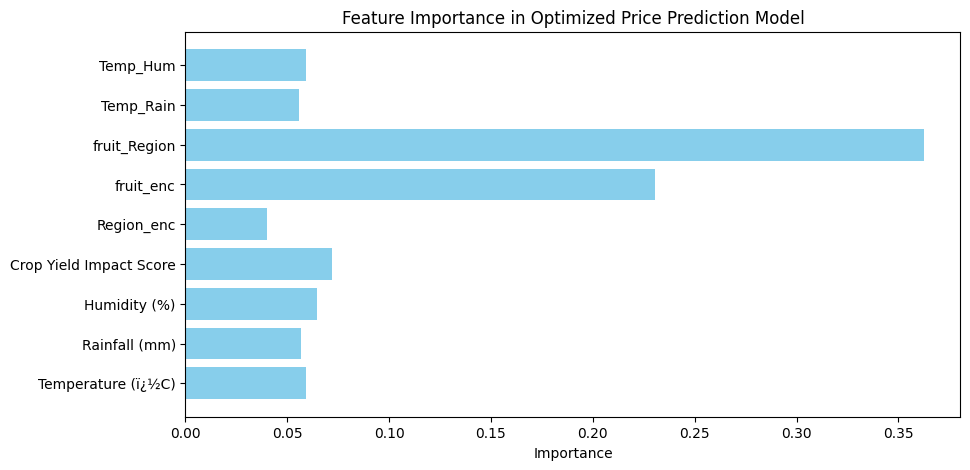

In [12]:
# =========================================
# STEP 10: FEATURE IMPORTANCE
# =========================================
feature_importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance in Optimized Price Prediction Model")
plt.show()


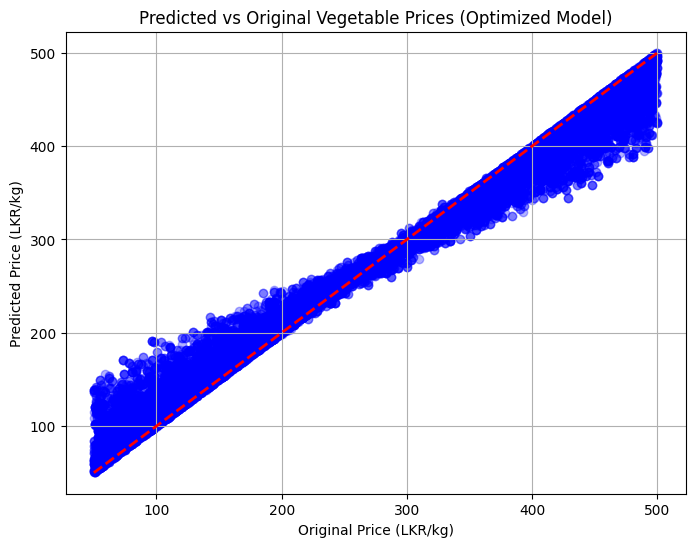

In [13]:
# =========================================
# STEP 11: PREDICTED VS ORIGINAL PRICE SCATTER
# =========================================
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  # perfect prediction line
plt.xlabel("Original Price (LKR/kg)")
plt.ylabel("Predicted Price (LKR/kg)")
plt.title("Predicted vs Original Vegetable Prices (Optimized Model)")
plt.grid(True)
plt.show()

In [14]:
# =========================================
# STEP 12: SAVE MODEL + ENCODERS
# =========================================
joblib.dump(rf_model, 'fruit_model.pkl')
joblib.dump(region_encoder, 'region_encoder.pkl')
joblib.dump(fruit_encoder, 'fruit_encoder.pkl')
print('Saved files in current working directory:')
print('- fruit_model.pkl')
print('- region_encoder.pkl')
print('- fruit_encoder.pkl')


Saved files in current working directory:
- fruit_model.pkl
- region_encoder.pkl
- fruit_encoder.pkl
